# ✍️ Signature Forgery Detection System
**ResNet18 + Albumentations | Binary Classification: Authentic vs Fake**

---
### Pipeline Overview
1. Mount Google Drive & load all 3 datasets via JSON mappings
2. Heavy augmentation with **Albumentations** (rotation, noise, ElasticTransform)
3. **Frozen ResNet18** backbone + trainable classification head
4. **BCEWithLogitsLoss** + Adam (lr=1e-4)
5. Validation: **Precision, Recall, F1, Confusion Matrix**
6. Inference with **confidence % output**

## 📦 Step 1: Install Dependencies

In [1]:
%%capture
!pip install albumentations==1.4.3 torch torchvision tqdm scikit-learn matplotlib seaborn Pillow

## 🔗 Step 2: Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted successfully!")

Mounted at /content/drive
✅ Drive mounted successfully!


## 📁 Step 3: Configure Dataset Paths
**→ Update the `DRIVE_BASE_PATH` to match your folder location in Drive.**

In [11]:
import os

# ============================================================
# ⚙⌘  CONFIGURE THIS: path to your dataset folder in Drive
# Example: '/content/drive/MyDrive/signature_dataset'
# ============================================================
DRIVE_BASE_PATH = '/content/drive/MyDrive/YOUR_DATASET_FOLDER_HERE'  # <---- UPDATE THIS WITH YOUR ACTUAL FOLDER PATH

# Each dataset folder is expected to contain:
#   - a JSON file  (labels/annotations)
#   - an image folder or images directly
DATASET_DIRS = [
    os.path.join(DRIVE_BASE_PATH, 'dataset1'),
    os.path.join(DRIVE_BASE_PATH, 'dataset2'),
    os.path.join(DRIVE_BASE_PATH, 'dataset3'),
]

# Verify folders exist
for d in DATASET_DIRS:
    status = '✅' if os.path.exists(d) else '❌ NOT FOUND'
    print(f"{status}  {d}")

❌ NOT FOUND  /content/drive/MyDrive/YOUR_DATASET_FOLDER_HERE/dataset1
❌ NOT FOUND  /content/drive/MyDrive/YOUR_DATASET_FOLDER_HERE/dataset2
❌ NOT FOUND  /content/drive/MyDrive/YOUR_DATASET_FOLDER_HERE/dataset3


In [18]:
import os
DOWNLOAD_SUB_DIR = os.path.join('/content/downloaded_dataset', 'train_test_split')
print(f"Contents of {DOWNLOAD_SUB_DIR}:")
!ls -F {DOWNLOAD_SUB_DIR}

# If this output shows 'dataset1/', 'dataset2/', 'dataset3/',
# then update DRIVE_BASE_PATH in cell cc738740 like this:
# DRIVE_BASE_PATH = DOWNLOAD_SUB_DIR
# Then re-run cell cc738740 and subsequent cells.

Contents of /content/downloaded_dataset/train_test_split:
Dataset1_Generic/  Dataset2_LargeDataset/


In [19]:
import os
DOWNLOAD_SUB_DIR = os.path.join('/content/downloaded_dataset', 'train_test_split')
print(f"Contents of {DOWNLOAD_SUB_DIR}:")
!ls -F {DOWNLOAD_SUB_DIR}

# If this output shows 'dataset1/', 'dataset2/', 'dataset3/',
# then update DRIVE_BASE_PATH in cell cc738740 like this:
# DRIVE_BASE_PATH = DOWNLOAD_SUB_DIR
# Then re-run cell cc738740 and subsequent cells.

Contents of /content/downloaded_dataset/train_test_split:
Dataset1_Generic/  Dataset2_LargeDataset/


In [20]:
import os
DOWNLOAD_SUB_DIR = os.path.join('/content/downloaded_dataset', 'train_test_split')
print(f"Contents of {DOWNLOAD_SUB_DIR}:")
!ls -F {DOWNLOAD_SUB_DIR}

# If this output shows 'dataset1/', 'dataset2/', 'dataset3/',
# then update DRIVE_BASE_PATH in cell cc738740 like this:
# DRIVE_BASE_PATH = DOWNLOAD_SUB_DIR
# Then re-run cell cc738740 and subsequent cells.

Contents of /content/downloaded_dataset/train_test_split:
Dataset1_Generic/  Dataset2_LargeDataset/


In [15]:
import os
DOWNLOAD_DIR = '/content/downloaded_dataset'
print(f"Contents of {DOWNLOAD_DIR}:")
!ls -F {DOWNLOAD_DIR}

# If the output shows a single directory, e.g., 'signature_data/',
# you might need to update DRIVE_BASE_PATH like this:
# DRIVE_BASE_PATH = os.path.join(DOWNLOAD_DIR, 'signature_data')
# Then re-run cell cc738740 and subsequent cells.

Contents of /content/downloaded_dataset:
split_metadata/  train_test_split/


In [16]:
import os
DOWNLOAD_DIR = '/content/downloaded_dataset'
print(f"Contents of {DOWNLOAD_DIR}:")
!ls -F {DOWNLOAD_DIR}

# If the output shows a single directory, e.g., 'signature_data/',
# you might need to update DRIVE_BASE_PATH like this:
# DRIVE_BASE_PATH = os.path.join(DOWNLOAD_DIR, 'signature_data')
# Then re-run cell cc738740 and subsequent cells.

Contents of /content/downloaded_dataset:
split_metadata/  train_test_split/


In [17]:
import os
DOWNLOAD_DIR = '/content/downloaded_dataset'
print(f"Contents of {DOWNLOAD_DIR}:")
!ls -F {DOWNLOAD_DIR}

# If the output shows a single directory, e.g., 'signature_data/',
# you might need to update DRIVE_BASE_PATH like this:
# DRIVE_BASE_PATH = os.path.join(DOWNLOAD_DIR, 'signature_data')
# Then re-run cell cc738740 and subsequent cells.

Contents of /content/downloaded_dataset:
split_metadata/  train_test_split/


In [12]:
%%capture
!pip install gdown

In [13]:
# File ID extracted from the provided Google Drive link
FILE_ID = '1MxO7jJGyrkz7k_kkRwMPCsL81SeTVU3O'
OUTPUT_ZIP_PATH = '/tmp/dataset.zip'
DOWNLOAD_DIR = '/content/downloaded_dataset'

print(f"Downloading dataset (file ID: {FILE_ID}) to {OUTPUT_ZIP_PATH}...")
!gdown --id {FILE_ID} -O {OUTPUT_ZIP_PATH}

import os
import zipfile

os.makedirs(DOWNLOAD_DIR, exist_ok=True)

print(f"Unzipping {OUTPUT_ZIP_PATH} to {DOWNLOAD_DIR}...")
with zipfile.ZipFile(OUTPUT_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(DOWNLOAD_DIR)

print(f"✅ Dataset downloaded and unzipped to {DOWNLOAD_DIR}")
print("Please manually inspect the contents of the unzipped folder to ensure the expected structure.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1MxO7jJGyrkz7k_kkRwMPCsL81SeTVU3O
From (redirected): https://drive.google.com/uc?id=1MxO7jJGyrkz7k_kkRwMPCsL81SeTVU3O&confirm=t&uuid=5dcda01a-2733-4397-985f-b67e6e52237c
To: /tmp/dataset.zip
100% 1.04G/1.04G [00:18<00:00, 56.7MB/s]
Unzipping /tmp/dataset.zip to /content/downloaded_dataset...
✅ Dataset downloaded and unzipped to /content/downloaded_dataset
Please manually inspect the contents of the unzipped folder to ensure the expected structure.


In [21]:
import os

# ============================================================
# ⚙⌘  CONFIGURE THIS: path to your dataset folder in Drive
# Example: '/content/drive/MyDrive/signature_dataset'
# ============================================================
DRIVE_BASE_PATH = '/content/downloaded_dataset/train_test_split'  # <---- UPDATED TO CORRECT DOWNLOADED PATH

# Each dataset folder is expected to contain:
#   - a JSON file  (labels/annotations)
#   - an image folder or images directly
DATASET_DIRS = [
    os.path.join(DRIVE_BASE_PATH, 'Dataset1_Generic'),
    os.path.join(DRIVE_BASE_PATH, 'Dataset2_LargeDataset'),
    # os.path.join(DRIVE_BASE_PATH, 'dataset3'), # dataset3 not found in downloaded archive
]

# Verify folders exist
for d in DATASET_DIRS:
    status = '✅' if os.path.exists(d) else '❌ NOT FOUND'
    print(f"{status}  {d}")

✅  /content/downloaded_dataset/train_test_split/Dataset1_Generic
✅  /content/downloaded_dataset/train_test_split/Dataset2_LargeDataset


## 🔍 Step 4: Explore & Auto-Detect Dataset Structure

In [4]:
import json
import glob
from pathlib import Path

def find_json_files(folder):
    """Recursively find all JSON files in a folder."""
    return glob.glob(os.path.join(folder, '**', '*.json'), recursive=True)

def find_image_files(folder):
    """Recursively find all image files."""
    exts = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']
    images = []
    for ext in exts:
        images.extend(glob.glob(os.path.join(folder, '**', ext), recursive=True))
    return images

# Explore each dataset directory
for d in DATASET_DIRS:
    if not os.path.exists(d):
        continue
    name = os.path.basename(d)
    jsons = find_json_files(d)
    images = find_image_files(d)
    print(f"\n📂 {name}")
    print(f"   JSON files  : {len(jsons)}")
    for j in jsons:
        print(f"     → {os.path.relpath(j, d)}")
    print(f"   Image files : {len(images)}")
    if images:
        # Show sample directory structure
        sample_dirs = list(set(os.path.dirname(img) for img in images[:5]))
        for sd in sample_dirs[:3]:
            print(f"     → {os.path.relpath(sd, d)}/")

## 📋 Step 5: Load & Parse All JSON Mappings

In [23]:
def load_json_safe(path):
    """Load a JSON file safely with encoding fallback."""
    for enc in ['utf-8', 'utf-8-sig', 'latin-1']:
        try:
            with open(path, 'r', encoding=enc) as f:
                return json.load(f)
        except (UnicodeDecodeError, json.JSONDecodeError):
            continue
    print(f"  ⚠️  Could not parse {path}")
    return None


def parse_mapping_to_records(json_data, dataset_dir, json_path):
    """
    Flexible parser that handles multiple JSON formats:
    Format A: [{"image": "path.jpg", "label": "Authentic"}, ...]
    Format B: {"image_path": "label", ...}
    Format C: {"images": [...], "labels": [...]}
    Format D: COCO-style with 'images', 'annotations', 'categories'
    """
    records = []  # list of (abs_image_path, label_int)

    # ---- Normalise label text → 0/1 --------------------------------
    def norm_label(raw):
        raw = str(raw).strip().lower()
        if raw in ['1', 'authentic', 'genuine', 'real', 'original', 'true', 'yes']:
            return 1
        if raw in ['0', 'fake', 'forged', 'forge', 'forgery', 'false', 'no']:
            return 0
        return None  # unknown

    # ---- Resolve image path relative to dataset dir ----------------
    def resolve_img(rel_path):
        candidates = [
            os.path.join(dataset_dir, rel_path),
            os.path.join(os.path.dirname(json_path), rel_path),
            rel_path,  # absolute path
        ]
        for c in candidates:
            if os.path.isfile(c):
                return os.path.abspath(c)
        return None

    # ---- Format A: list of dicts ------------------------------------
    if isinstance(json_data, list):
        for item in json_data:
            if not isinstance(item, dict):
                continue
            # find image key
            img_key = next((k for k in item if k.lower() in
                            ['image', 'image_path', 'img', 'filename', 'file', 'path']), None)
            lbl_key = next((k for k in item if k.lower() in
                            ['label', 'class', 'category', 'type', 'target']), None)
            if not img_key or not lbl_key:
                continue
            img_path = resolve_img(str(item[img_key]))
            lbl = norm_label(item[lbl_key])
            if img_path and lbl is not None:
                records.append((img_path, lbl))

    # ---- Format B: flat dict {path: label} -------------------------
    elif isinstance(json_data, dict) and not any(
            k in json_data for k in ['images', 'annotations', 'data', 'samples']):
        for k, v in json_data.items():
            lbl = norm_label(v);
            if lbl is not None:
                img_path = resolve_img(k);
                if img_path:
                    records.append((img_path, lbl))

    # ---- Format C: {images: [...], labels: [...]} ------------------
    elif isinstance(json_data, dict) and 'images' in json_data and 'labels' in json_data:
        for img, lbl in zip(json_data['images'], json_data['labels']):
            img_path = resolve_img(str(img))
            lbl = norm_label(lbl)
            if img_path and lbl is not None:
                records.append((img_path, lbl))

    # ---- Format D: COCO-style --------------------------------------
    elif isinstance(json_data, dict) and 'annotations' in json_data:
        id2file = {img['id']: img['file_name']
                   for img in json_data.get('images', [])}
        id2cat  = {cat['id']: cat['name']
                   for cat in json_data.get('categories', [])}
        for ann in json_data['annotations']:
            fname = id2file.get(ann.get('image_id'))
            cat   = id2cat.get(ann.get('category_id'), '')
            if fname:
                img_path = resolve_img(fname)
                lbl = norm_label(cat)
                if img_path and lbl is not None:
                    records.append((img_path, lbl))

    # ---- Format E: {data: [{image, label}]} ------------------------
    elif isinstance(json_data, dict) and 'data' in json_data:
        return parse_mapping_to_records(json_data['data'], dataset_dir, json_path)

    return records


# ---------------------------------------------------------------
# Load all datasets
# ---------------------------------------------------------------
all_records = []   # (image_path, label)

for dataset_dir in DATASET_DIRS:
    if not os.path.exists(dataset_dir):
        continue
    name = os.path.basename(dataset_dir)
    json_files = find_json_files(dataset_dir)
    ds_records = []

    for jf in json_files:
        data = load_json_safe(jf)
        if data is None:
            continue
        recs = parse_mapping_to_records(data, dataset_dir, jf)
        ds_records.extend(recs)
        print(f"  📄 {os.path.relpath(jf, dataset_dir):40s}  →  {len(recs):4d} records")

    # De-duplicate within dataset
    seen = set()
    unique = []
    for r in ds_records:
        if r[0] not in seen:
            seen.add(r[0])
            unique.append(r)

    auth  = sum(1 for _, l in unique if l == 1)
    fake  = sum(1 for _, l in unique if l == 0)
    print(f"\n  ✅ {name}: {len(unique)} records  |  Authentic={auth}  Fake={fake}\n")
    all_records.extend(unique)

print(f"\n{'='*50}")
print(f"TOTAL  : {len(all_records)} images")
print(f"Authentic: {sum(1 for _,l in all_records if l==1)}")
print(f"Fake     : {sum(1 for _,l in all_records if l==0)}")

  📄 Dataset1_Generic_metadata.json            →     0 records

  ✅ Dataset1_Generic: 0 records  |  Authentic=0  Fake=0


  ✅ Dataset2_LargeDataset: 0 records  |  Authentic=0  Fake=0


TOTAL  : 0 images
Authentic: 0
Fake     : 0


## 🛡️ Step 5b: Fallback — Folder-Based Loading
**Run this cell only if the JSON parsing above found 0 records.**
It scans for `authentic/` and `fake/` sub-folders directly.

In [38]:
if len(all_records) == 0:
    print("JSON parsing found 0 records — falling back to folder-name detection.")

    # Only defining IMAGE EXTENSIONS here as LABEL_MAP approach was too restrictive
    IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

    for dataset_dir in DATASET_DIRS:
        if not os.path.exists(dataset_dir):
            continue
        for root, dirs, files in os.walk(dataset_dir):
            current_folder_name = os.path.basename(root).strip().lower()
            determined_label = None

            if '_forg' in current_folder_name: # If folder name contains '_forg', it's fake
                determined_label = 0 # Fake
            elif current_folder_name.isdigit(): # If folder name is purely numeric, it's authentic
                determined_label = 1 # Authentic

            if determined_label is not None:
                for f in files:
                    if Path(f).suffix.lower() in IMG_EXTS:
                        all_records.append((os.path.join(root, f), determined_label))

    auth = sum(1 for _,l in all_records if l==1)
    fake = sum(1 for _,l in all_records if l==0)
    print(f"Fallback found {len(all_records)} images  |  Authentic={auth}  Fake={fake}")
else:
    print(f"✅ {len(all_records)} records already loaded from JSON — skipping fallback.")

JSON parsing found 0 records — falling back to folder-name detection.
Fallback found 35029 images  |  Authentic=17698  Fake=17331


## 🖼️ Step 6: Visualise Sample Images

In [25]:
import matplotlib.pyplot as plt
from PIL import Image
import random

authentic = [(p, l) for p, l in all_records if l == 1]
fake      = [(p, l) for p, l in all_records if l == 0]

n_show = min(4, min(len(authentic), len(fake)))
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 5))
fig.suptitle('Sample Signatures', fontsize=14, fontweight='bold')

for i in range(n_show):
    for row, (samples, title) in enumerate([(authentic, 'Authentic ✅'), (fake, 'Fake ❌')]):
        img_path, _ = random.choice(samples)
        img = Image.open(img_path).convert('RGB')
        axes[row][i].imshow(img, cmap='gray')
        axes[row][i].set_title(title if i == 0 else '', fontsize=10)
        axes[row][i].axis('off')

plt.tight_layout()
plt.show()

ValueError: Number of columns must be a positive integer, not 0

<Figure size 0x500 with 0 Axes>

In [37]:
import os

for d_dir in DATASET_DIRS:
    print(f"\nRecursive listing for: {d_dir}")
    !ls -RF {d_dir}

Streaming output truncated to the last 5000 lines.
0699_01.jpg  0699_03.jpg  0699_05.jpg  0699_07.jpg  0699_09.jpg  0699_11.jpg
0699_02.jpg  0699_04.jpg  0699_06.jpg  0699_08.jpg  0699_10.jpg

/content/downloaded_dataset/train_test_split/Dataset2_LargeDataset/train/0699_forg:
0699F_01.jpg  0699F_04.jpg  0699F_07.jpg  0699F_10.jpg
0699F_02.jpg  0699F_05.jpg  0699F_08.jpg  0699F_11.jpg
0699F_03.jpg  0699F_06.jpg  0699F_09.jpg

/content/downloaded_dataset/train_test_split/Dataset2_LargeDataset/train/0700:
0700_01.jpg  0700_03.jpg  0700_05.jpg  0700_07.jpg  0700_09.jpg  0700_11.jpg
0700_02.jpg  0700_04.jpg  0700_06.jpg  0700_08.jpg  0700_10.jpg

/content/downloaded_dataset/train_test_split/Dataset2_LargeDataset/train/0700_forg:
0700F_01.jpg  0700F_04.jpg  0700F_07.jpg  0700F_10.jpg
0700F_02.jpg  0700F_05.jpg  0700F_08.jpg  0700F_11.jpg
0700F_03.jpg  0700F_06.jpg  0700F_09.jpg

/content/downloaded_dataset/train_test_split/Dataset2_LargeDataset/train/0701:
0701_01.jpg  0701_03.jpg  0701_05.j

## ✂️ Step 7: Train / Validation Split

In [39]:
import random
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)

paths  = [r[0] for r in all_records]
labels = [r[1] for r in all_records]

# Stratified split so both classes appear in val
train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths, labels,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

print(f"Train : {len(train_paths):4d}  (Auth={sum(train_labels):3d}  Fake={len(train_labels)-sum(train_labels):3d})")
print(f"Val   : {len(val_paths):4d}  (Auth={sum(val_labels):3d}  Fake={len(val_labels)-sum(val_labels):3d})")

Train : 28023  (Auth=14158  Fake=13865)
Val   : 7006  (Auth=3540  Fake=3466)


## 🎨 Step 8: Heavy Augmentation with Albumentations

In [53]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

IMG_SIZE = 224   # ResNet18 expects 224×224

# -----------------------------------------------------------------
# TRAINING augmentation  — aggressive to fight overfitting
# -----------------------------------------------------------------
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    # Geometric
    A.Rotate(limit=10, border_mode=0, p=0.7),          # small pen-angle variation
    A.ShiftScaleRotate(shift_limit=0.05,
                       scale_limit=0.10,
                       rotate_limit=8,
                       border_mode=0, p=0.5),
    A.HorizontalFlip(p=0.3),

    # Elastic / distortion — simulates different pen pressures
    A.ElasticTransform(alpha=40, sigma=6,
                       alpha_affine=40 * 0.05, # Changed to a single float value
                       border_mode=0, p=0.5),
    A.GridDistortion(num_steps=5, distort_limit=0.15,
                     border_mode=0, p=0.3),

    # Noise & blur — simulate scan / photo quality
    A.GaussNoise(var_limit=(5.0, 30.0), p=0.5),
    A.OneOf([
        A.MotionBlur(blur_limit=3, p=1.0),
        A.GaussianBlur(blur_limit=3, p=1.0),
    ], p=0.3),

    # Photometric
    A.RandomBrightnessContrast(brightness_limit=0.2,
                                contrast_limit=0.2, p=0.5),
    A.CoarseDropout(max_holes=6, max_height=16,
                    max_width=16, fill_value=255, p=0.3),

    # Normalise to ImageNet stats
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# -----------------------------------------------------------------
# VALIDATION transform  — only resize + normalise
# -----------------------------------------------------------------
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print("✅ Augmentation pipelines ready.")

✅ Augmentation pipelines ready.


/usr/local/lib/python3.12/dist-packages/albumentations/augmentations/blur/transforms.py:190: UserWarning: blur_limit and sigma_limit minimum value can not be both equal to 0. blur_limit minimum value changed to 3.
  warnings.warn(


## 📦 Step 9: PyTorch Dataset & DataLoader

In [54]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

class SignatureDataset(Dataset):
    """Custom dataset for signature images with Albumentations transforms."""

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label    = self.labels[idx]

        # Load as RGB; convert grayscale sigs to RGB for ResNet
        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Warning: could not open {img_path}: {e}")
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=255)

        img_np = np.array(img)

        if self.transform:
            augmented = self.transform(image=img_np)
            img_tensor = augmented['image']          # (C, H, W) float32
        else:
            img_tensor = torch.from_numpy(
                img_np.transpose(2, 0, 1)).float() / 255.0

        return img_tensor, torch.tensor(label, dtype=torch.float32)


# Datasets
train_dataset = SignatureDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = SignatureDataset(val_paths,   val_labels,   transform=val_transform)

# DataLoaders
BATCH_SIZE = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True, drop_last=True)

val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)

print(f"✅ Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

✅ Train batches: 1751  |  Val batches: 438


## 🧠 Step 10: Model — Frozen ResNet18 + Custom Head

In [41]:
import torch
import torch.nn as nn
import torchvision.models as models

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Using device: {DEVICE}")

# ---- 1. Load pretrained ResNet18 backbone ----------------------
backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# ---- 2. Freeze ALL backbone parameters -------------------------
for param in backbone.parameters():
    param.requires_grad = False

# Optionally unfreeze the last residual block for fine-tuning
# (Comment out if you want fully frozen backbone)
for param in backbone.layer4.parameters():
    param.requires_grad = True

backbone_out_features = backbone.fc.in_features   # 512 for ResNet18

# ---- 3. Replace FC with custom classification head -------------
backbone.fc = nn.Sequential(
    nn.Linear(backbone_out_features, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),

    nn.Linear(256, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.3),

    nn.Linear(64, 1)   # raw logit — BCEWithLogitsLoss handles sigmoid
)

model = backbone.to(DEVICE)

# ---- 4. Parameter count summary --------------------------------
total  = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = total - trainable

print(f"\n📊 Model Summary")
print(f"   Total params    : {total:,}")
print(f"   Trainable       : {trainable:,}  ({100*trainable/total:.1f}%)")
print(f"   Frozen (backbone): {frozen:,}  ({100*frozen/total:.1f}%)")

🖥️  Using device: cuda

📊 Model Summary
   Total params    : 11,324,993
   Trainable       : 8,542,209  (75.4%)
   Frozen (backbone): 2,782,784  (24.6%)


## ⚙️ Step 11: Loss, Optimizer & Scheduler

In [43]:
import torch.optim as optim

# Handle class imbalance: upweight the Fake class
n_auth = sum(train_labels)
n_fake = len(train_labels) - n_auth
if n_fake > 0:
    pos_weight = torch.tensor([n_fake / n_auth], dtype=torch.float32).to(DEVICE)
else:
    pos_weight = None
print(f"pos_weight for BCEWithLogitsLoss: {pos_weight}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# Only optimise trainable params
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

# ReduceLROnPlateau: halve LR if val loss stalls for 3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

print("✅ Loss / Optimizer / Scheduler configured.")

pos_weight for BCEWithLogitsLoss: tensor([0.9793], device='cuda:0')
✅ Loss / Optimizer / Scheduler configured.


## 🏋️ Step 12: Training & Validation Loop

In [55]:
from tqdm.notebook import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

NUM_EPOCHS    = 10
THRESHOLD     = 0.5      # probability threshold for Fake/Authentic
EARLY_STOP    = 7        # stop if val loss does not improve

history = {
    'train_loss': [], 'val_loss': [],
    'val_precision': [], 'val_recall': [],
    'val_f1': [], 'val_acc': []
}

best_val_loss   = float('inf')
patience_count  = 0
CKPT_PATH       = '/content/best_signature_model.pth'


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for imgs, lbls in tqdm(loader, desc='  Train', leave=False):
        imgs = imgs.to(device)
        lbls = lbls.to(device).unsqueeze(1)   # (B,1)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, lbls)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc='  Val  ', leave=False):
            imgs = imgs.to(device)
            lbls = lbls.to(device).unsqueeze(1)
            logits = model(imgs)
            loss   = criterion(logits, lbls)
            total_loss += loss.item() * imgs.size(0)

            probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            preds = (probs >= threshold).astype(int)
            all_preds.extend(preds.tolist())
            all_labels.extend(lbls.squeeze(1).cpu().numpy().astype(int).tolist())

    avg_loss  = total_loss / len(loader.dataset)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall    = recall_score(all_labels, all_preds, zero_division=0)
    f1        = f1_score(all_labels, all_preds, zero_division=0)
    acc       = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)

    return avg_loss, precision, recall, f1, acc


# ===================== MAIN TRAINING LOOP =====================
print(f"🚀 Training for up to {NUM_EPOCHS} epochs  |  Early stop patience={EARLY_STOP}\n")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, precision, recall, f1, acc = validate(model, val_loader,
                                                     criterion, DEVICE, THRESHOLD)
    scheduler.step(val_loss)

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_precision'].append(precision)
    history['val_recall'].append(recall)
    history['val_f1'].append(f1)
    history['val_acc'].append(acc)

    # Best model checkpoint
    improved = ''
    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(model.state_dict(), CKPT_PATH)
        improved = '  ✅ saved'
    else:
        patience_count += 1

    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
          f"Train Loss: {train_loss:.4f}  "
          f"Val Loss: {val_loss:.4f}  "
          f"Prec: {precision:.3f}  Rec: {recall:.3f}  "
          f"F1: {f1:.3f}  Acc: {acc:.3f}"
          + improved)

    if patience_count >= EARLY_STOP:
        print(f"\n⏹️  Early stopping triggered after {epoch} epochs.")
        break

print(f"\n🏆 Best validation loss: {best_val_loss:.4f}")
print(f"   Model saved to: {CKPT_PATH}")

🚀 Training for up to 10 epochs  |  Early stop patience=7



  Train:   0%|          | 0/1751 [00:00<?, ?it/s]

  Val  :   0%|          | 0/438 [00:00<?, ?it/s]

Epoch [01/10]  Train Loss: 0.6401  Val Loss: 0.5377  Prec: 0.717  Rec: 0.705  F1: 0.711  Acc: 0.711  ✅ saved


  Train:   0%|          | 0/1751 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/438 [00:00<?, ?it/s]

Epoch [09/10]  Train Loss: 0.4235  Val Loss: 0.3375  Prec: 0.852  Rec: 0.858  F1: 0.855  Acc: 0.853  ✅ saved


  Train:   0%|          | 0/1751 [00:00<?, ?it/s]

  Val  :   0%|          | 0/438 [00:00<?, ?it/s]

Epoch [10/10]  Train Loss: 0.4056  Val Loss: 0.3697  Prec: 0.815  Rec: 0.852  F1: 0.833  Acc: 0.827

🏆 Best validation loss: 0.3375
   Model saved to: /content/best_signature_model.pth


## 📈 Step 13: Training Curves

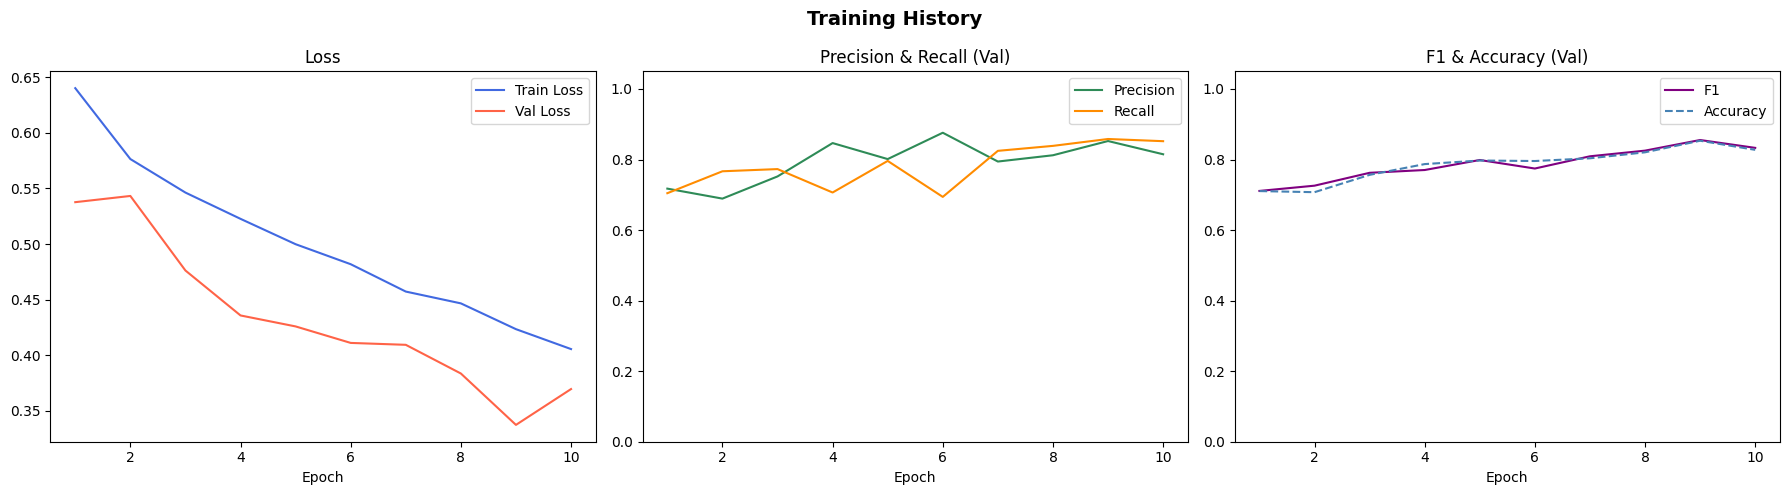

📊 Plot saved to /content/training_history.png


In [56]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

# Loss
axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='royalblue')
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='tomato')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

# Precision & Recall
axes[1].plot(epochs_ran, history['val_precision'], label='Precision', color='seagreen')
axes[1].plot(epochs_ran, history['val_recall'],    label='Recall',    color='darkorange')
axes[1].set_title('Precision & Recall (Val)'); axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1.05)

# F1 & Accuracy
axes[2].plot(epochs_ran, history['val_f1'],  label='F1',       color='purple')
axes[2].plot(epochs_ran, history['val_acc'], label='Accuracy', color='steelblue', linestyle='--')
axes[2].set_title('F1 & Accuracy (Val)'); axes[2].legend()
axes[2].set_xlabel('Epoch'); axes[2].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Plot saved to /content/training_history.png")

## 🔥 Step 14: Confusion Matrix on Validation Set

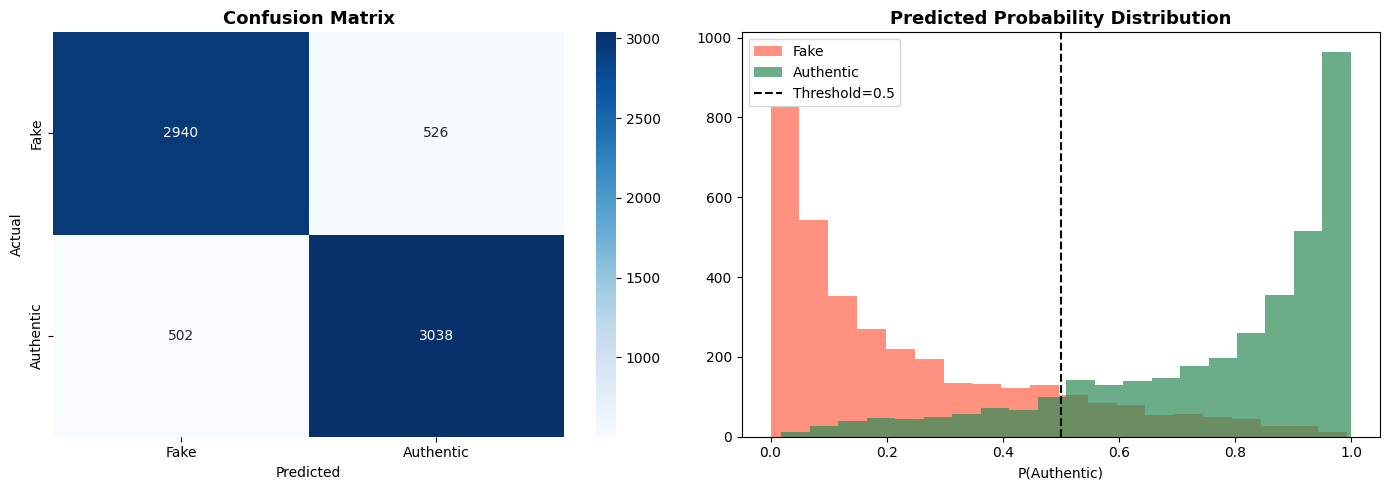


📑 Classification Report:
              precision    recall  f1-score   support

        Fake       0.85      0.85      0.85      3466
   Authentic       0.85      0.86      0.86      3540

    accuracy                           0.85      7006
   macro avg       0.85      0.85      0.85      7006
weighted avg       0.85      0.85      0.85      7006



In [57]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Load best weights
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs  = imgs.to(DEVICE)
        logit = model(imgs)
        prob  = torch.sigmoid(logit).squeeze(1).cpu().numpy()
        pred  = (prob >= THRESHOLD).astype(int)
        all_probs.extend(prob.tolist())
        all_preds.extend(pred.tolist())
        all_labels.extend(lbls.numpy().astype(int).tolist())

cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Authentic'],
            yticklabels=['Fake', 'Authentic'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Probability distribution
probs_auth = [p for p, l in zip(all_probs, all_labels) if l == 1]
probs_fake = [p for p, l in zip(all_probs, all_labels) if l == 0]
axes[1].hist(probs_fake, bins=20, alpha=0.7, color='tomato',    label='Fake')
axes[1].hist(probs_auth, bins=20, alpha=0.7, color='seagreen',  label='Authentic')
axes[1].axvline(THRESHOLD, color='black', linestyle='--', label=f'Threshold={THRESHOLD}')
axes[1].set_title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('P(Authentic)'); axes[1].legend()

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📑 Classification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=['Fake', 'Authentic']))

## 🔍 Step 15: Inference — Predict Single Image with Confidence %

/tmp/ipykernel_4776/3703521443.py:57: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4776/3703521443.py:57: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4776/3703521443.py:58: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_4776/3703521443.py:58: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing

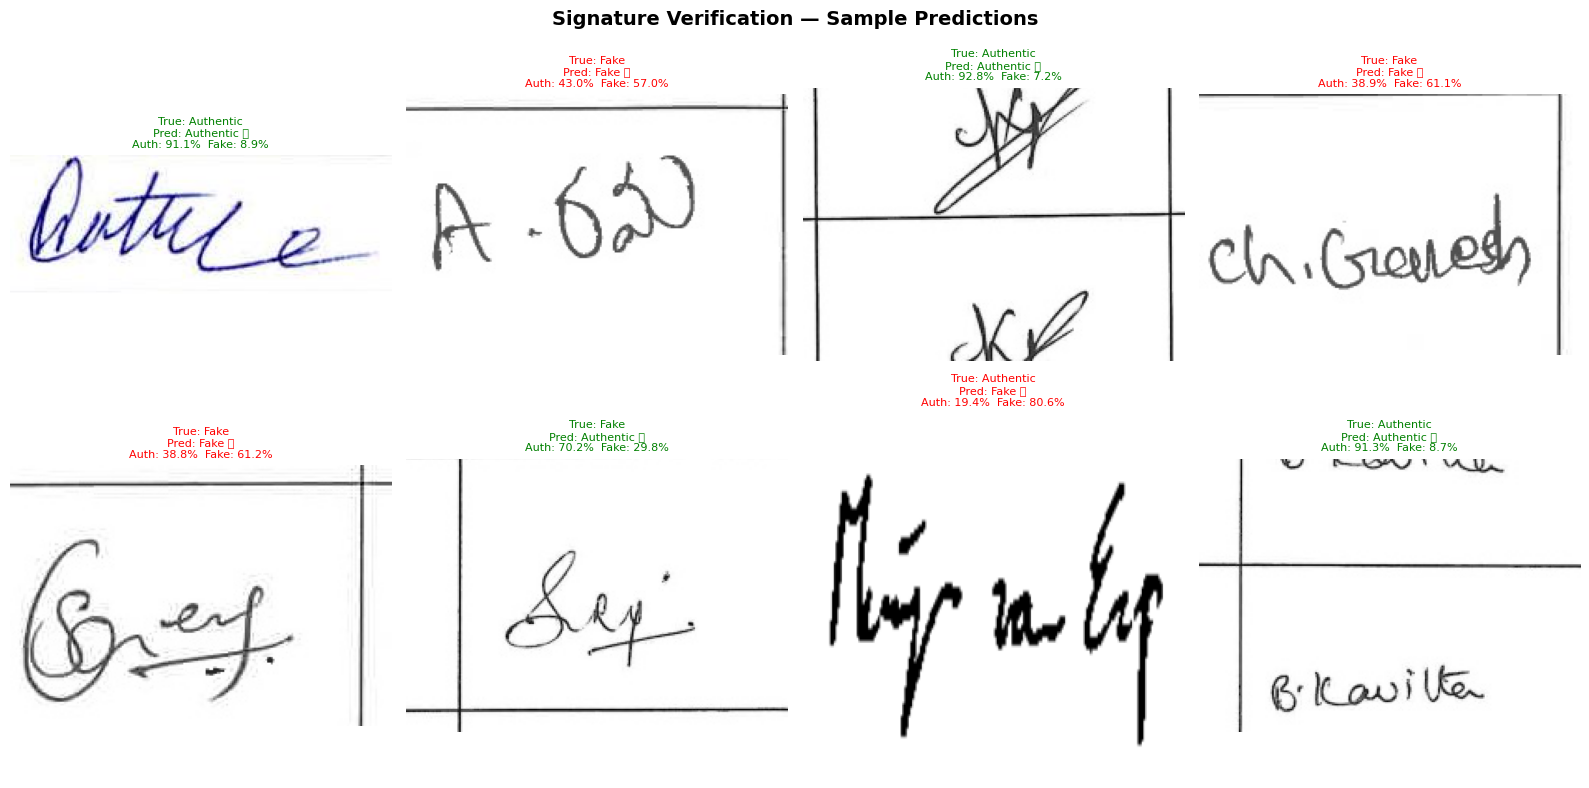

In [58]:
def predict_signature(image_path, model, device, threshold=0.5):
    """
    Predict whether a signature is Authentic or Fake.

    Returns:
        dict with keys: verdict, confidence_pct, authentic_pct, fake_pct
    """
    model.eval()

    img = Image.open(image_path).convert('RGB')
    img_np = np.array(img)

    aug = val_transform(image=img_np)
    tensor = aug['image'].unsqueeze(0).to(device)   # (1, C, H, W)

    with torch.no_grad():
        logit = model(tensor)
        prob_authentic = torch.sigmoid(logit).item()  # P(Authentic)

    prob_fake = 1.0 - prob_authentic
    verdict   = 'Authentic ✅' if prob_authentic >= threshold else 'Fake ❌'
    confidence = max(prob_authentic, prob_fake) * 100

    return {
        'verdict'        : verdict,
        'confidence_pct' : f"{confidence:.1f}%",
        'authentic_pct'  : f"{prob_authentic*100:.1f}%",
        'fake_pct'       : f"{prob_fake*100:.1f}%",
    }


# ---- Demo: run on a few validation samples ---------------------
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Signature Verification — Sample Predictions', fontsize=14, fontweight='bold')

sample_indices = random.sample(range(len(val_paths)), min(8, len(val_paths)))

for ax, idx in zip(axes.flatten(), sample_indices):
    img_path  = val_paths[idx]
    true_lbl  = 'Authentic' if val_labels[idx] == 1 else 'Fake'
    result    = predict_signature(img_path, model, DEVICE)

    img = Image.open(img_path).convert('RGB')
    color = 'green' if result['verdict'].startswith('Authentic') else 'red'

    ax.imshow(img)
    ax.set_title(
        f"True: {true_lbl}\n"
        f"Pred: {result['verdict']}\n"
        f"Auth: {result['authentic_pct']}  Fake: {result['fake_pct']}",
        fontsize=8, color=color
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 📂 Step 16: Predict on a New Image (Upload Your Own)
Run this cell to upload any signature image and get a verdict.

📤 Upload a signature image:


Saving 7-005_08.jpg to 7-005_08.jpg


/tmp/ipykernel_4776/2110372965.py:19: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


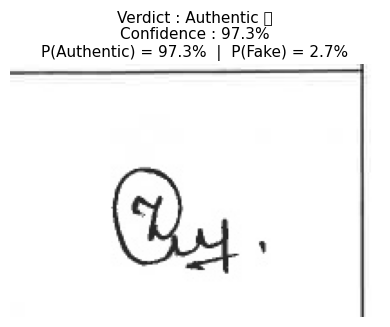


📊 7-005_08.jpg
   verdict             : Authentic ✅
   confidence_pct      : 97.3%
   authentic_pct       : 97.3%
   fake_pct            : 2.7%


In [64]:
from google.colab import files

print("📤 Upload a signature image:")
uploaded = files.upload()

for fname in uploaded.keys():
    result = predict_signature(fname, model, DEVICE)

    img = Image.open(fname).convert('RGB')
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(
        f"Verdict : {result['verdict']}\n"
        f"Confidence : {result['confidence_pct']}\n"
        f"P(Authentic) = {result['authentic_pct']}  |  P(Fake) = {result['fake_pct']}",
        fontsize=11
    )
    plt.tight_layout()
    plt.show()

    print(f"\n📊 {fname}")
    for k, v in result.items():
        print(f"   {k:20s}: {v}")

## 💾 Step 17: Save Model to Google Drive

In [60]:
import shutil

SAVE_DIR = os.path.join(DRIVE_BASE_PATH, 'model_outputs')
os.makedirs(SAVE_DIR, exist_ok=True)

shutil.copy(CKPT_PATH,                       os.path.join(SAVE_DIR, 'best_model.pth'))
shutil.copy('/content/training_history.png', os.path.join(SAVE_DIR, 'training_history.png'))
shutil.copy('/content/confusion_matrix.png', os.path.join(SAVE_DIR, 'confusion_matrix.png'))
shutil.copy('/content/sample_predictions.png', os.path.join(SAVE_DIR, 'sample_predictions.png'))

# Also save a small metadata JSON
import json
meta = {
    'architecture': 'ResNet18 (frozen backbone + custom head)',
    'img_size': IMG_SIZE,
    'threshold': THRESHOLD,
    'best_val_loss': best_val_loss,
    'final_precision': history['val_precision'][-1],
    'final_recall'   : history['val_recall'][-1],
    'final_f1'       : history['val_f1'][-1],
    'train_samples'  : len(train_paths),
    'val_samples'    : len(val_paths),
}
with open(os.path.join(SAVE_DIR, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)

print(f"✅ All outputs saved to: {SAVE_DIR}")
for fname in os.listdir(SAVE_DIR):
    print(f"   📄 {fname}")

✅ All outputs saved to: /content/downloaded_dataset/train_test_split/model_outputs
   📄 best_model.pth
   📄 confusion_matrix.png
   📄 model_meta.json
   📄 sample_predictions.png
   📄 training_history.png
